Intall stuff


In [ ]:
%pip install matplotlib

In [2]:
import matplotlib.pyplot as plt
import time
import random

In [3]:
from tspd_utils import generate_nodes, compute_distance_matrix
from hga_solver import hga_solve
from grasp_solver import grasp_solve
from hga_shc import hga_shc_solve


Nodes      | Paper HGA    | GRASP        | HSC         
-------------------------------------------------------
5          | 19.83        | 19.83        | 19.83       
10         | 32.06        | 27.07        | 28.49       
15         | 28.67        | 37.52        | 28.67       
20         | 44.10        | 49.13        | 43.86       
25         | 45.28        | 55.84        | 46.58       
30         | 50.82        | 75.02        | 49.30       
50         | 72.63        | 124.57       | 68.17       
100        | 93.53        | 251.74       | 93.42       
200        | 128.45       | 512.57       | 128.45      
500        | 202.42       | 1255.34      | 202.42      


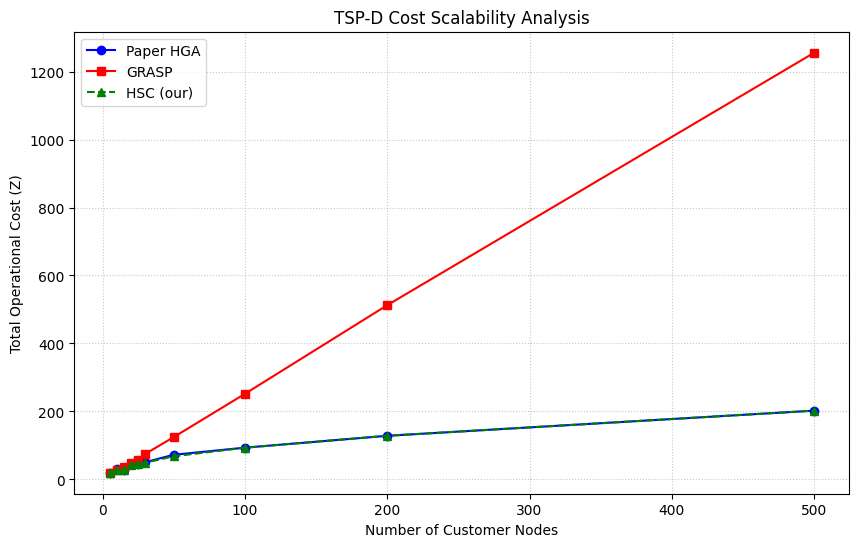

In [8]:
def run_scalability_test():
    # Defining the range of nodes to test
    # Note: 100 nodes may take significant time due to O(n^3) split complexity
    node_sizes = [5, 10, 15, 20, 25, 30,50,100,200,500] 
    seed = 42
    
    paper_costs = []
    grasp_costs = []
    hsc_costs = []

    print(f"{'Nodes':<10} | {'Paper HGA':<12} | {'GRASP':<12} | {'HSC ':<12}")
    print("-" * 55)

    for size in node_sizes:
        # [span_3](start_span)Generate identical coordinates for fair comparison[span_3](end_span)
        nodes = generate_nodes(size, seed=seed)
        dist_matrix = compute_distance_matrix(nodes)
        
        # 1. [span_4](start_span)Paper Algorithm[span_4](end_span)
        random.seed(seed)
        p_cost = hga_solve(nodes, dist_matrix, iterations=100, pop_size=20)
        paper_costs.append(p_cost)
        
        # 2. [span_5](start_span)GRASP Baseline[span_5](end_span)
        random.seed(seed)
        g_cost = grasp_solve(nodes, dist_matrix, iterations=100)
        grasp_costs.append(g_cost)
        
        # 3. [span_6](start_span)HSC IE Team Algorithm[span_6](end_span)
        random.seed(seed)
        h_cost = hga_shc_solve(nodes, dist_matrix, iterations=100, pop_size=20)
        hsc_costs.append(h_cost)
        
        print(f"{size:<10} | {p_cost:<12.2f} | {g_cost:<12.2f} | {h_cost:<12.2f}")

    # Plotting the results
    plt.figure(figsize=(10, 6))
    plt.plot(node_sizes, paper_costs, label='Paper HGA', marker='o', color='blue')
    plt.plot(node_sizes, grasp_costs, label='GRASP', marker='s', color='red')
    plt.plot(node_sizes, hsc_costs, label='HSC (our)', marker='^', color='green', linestyle='--')

    plt.title("TSP-D Cost Scalability Analysis")
    plt.xlabel("Number of Customer Nodes")
    plt.ylabel("Total Operational Cost (Z)")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    
    
    plt.show()

if __name__ == "__main__":
    run_scalability_test()